# TP Module 2 — Explicabilité (XAI) : Grad-CAM, Integrated Gradients, SHAP & LIME

**Formation avancée en Deep Learning avec PyTorch — Computer Vision & Séries temporelles**

*Bassem Ben Hamed — ENETCOM, Université de Sfax*

---

## Objectifs du TP

À l'issue de ce TP, vous serez capable de :

1. Situer les familles de méthodes **XAI** (gradient, perturbation, théorie des jeux, attention) et choisir selon la situation
2. **Implémenter à la main** (PyTorch pur) les attributions de référence : **Saliency**, **Grad-CAM**, **Integrated Gradients**, **Occlusion**
3. Vérifier **numériquement** l'axiome de **complétude** des Integrated Gradients
4. Approcher les **valeurs de Shapley** par **Expected Gradients / GradientSHAP**
5. Construire une explication **LIME** par superpixels (régression linéaire locale pondérée)
6. **Croiser vos implémentations** avec la bibliothèque officielle **Captum**
7. **Auditer** le modèle ResNet18 fine-tuné au TP 04 : vérifier qu'il « regarde la lésion » et non un artefact

## Pré-requis

- **TP 04** (`04_transfer_learning_finetuning.ipynb`) — on réutilise le **checkpoint** du modèle ResNet18/DermaMNIST
- Bibliothèques : `torch`, `torchvision`, `medmnist`, `numpy`, `matplotlib`, `scikit-learn`
- Optionnelles (détectées automatiquement) : `scikit-image` (superpixels LIME), `captum` (validation croisée), `shap`

## Dataset & modèle

On reste sur **DermaMNIST** (7 classes de lésions cutanées) et le **modèle entraîné au TP 04**. Expliquer un modèle **médical** est un cas d'usage canonique de la XAI : un clinicien n'accepte pas une boîte noire, et l'on veut détecter les **raccourcis** (le réseau qui se base sur un marqueur, une règle, un coin d'image plutôt que sur la lésion). Si le checkpoint du TP 04 est absent, un entraînement rapide (feature extraction, 5 epochs) est lancé **automatiquement** pour rendre ce TP autonome.

## Partie I — Rappels théoriques

### I.1 Pourquoi expliquer un modèle ?

- **Confiance** : un expert (radiologue, dermatologue) ne signe pas un diagnostic produit par une *boîte noire*.
- **Conformité** : IA Act, FDA, RGPD (art. 22) — *droit à l'explication* d'une décision automatisée.
- **Débogage** : détecter les *shortcuts* — corrélations fallacieuses (fond, règle graduée, vignette d'hôpital) que le modèle exploite au lieu du signal pertinent.
- **Sécurité** : caractériser les modes de défaillance avant la mise en production.

On distingue les explications **locales** (pourquoi *cette* image ?) des **globales** (comportement moyen), et les méthodes **post-hoc** (appliquées à un modèle déjà entraîné) des modèles **intrinsèquement** interprétables.

| Famille | Principe | Exemples | Coût |
|---|---|---|---|
| Gradient-based | $\nabla_x f$ et variantes spatialisées | Saliency, Grad-CAM, Integrated Gradients | Faible (1 backward) |
| Perturbation | Masquer / modifier l'entrée, mesurer l'effet | Occlusion, RISE, LIME | Élevé ($N$ forward) |
| Approximation locale | Modèle linéaire interprétable autour de $x$ | LIME | Moyen |
| Théorie des jeux | Valeurs de Shapley sur les features | SHAP, GradientSHAP | Élevé |
| Attention | Cartes d'attention multi-couches | Attention Rollout (ViT) | Faible |

Ce TP couvre **une méthode par famille** (l'attention est réservée aux ViT du Module 4).

### I.2 Saliency maps & Grad-CAM

**Saliency (Simonyan et al., 2014)** — la sensibilité du logit de la classe $c$ à chaque pixel :
$$
S(x) = \left| \frac{\partial f_c(x)}{\partial x} \right|, \qquad S_{ij} = \max_{\text{canaux}} \left| \frac{\partial f_c}{\partial x_{ij}} \right|.
$$
Un seul *backward* suffit. Bruitée mais quasi gratuite.

**Grad-CAM (Selvaraju et al., ICCV 2017)** — localise *où* le réseau regarde, au niveau d'une couche convolutive cible (typiquement la **dernière**, `layer4[-1]` pour un ResNet). Soit $A^k \in \mathbb{R}^{H\times W}$ la $k$-ième *feature map* :
$$
\alpha_c^k = \underbrace{\frac{1}{H W}\sum_{i}\sum_{j} \frac{\partial f_c}{\partial A^k_{ij}}}_{\text{GAP du gradient}},
\qquad
L^{\text{Grad-CAM}}_c = \mathrm{ReLU}\!\left( \sum_k \alpha_c^k A^k \right).
$$
Le **ReLU** ne garde que les contributions *positives* (les régions qui *soutiennent* la classe). La carte (grossière, $\sim 4\times4$ ici) est ensuite **suréchantillonnée** à la taille de l'image. Grad-CAM est **class-discriminante** : changer la classe cible change la carte.

### I.3 Integrated Gradients — attribution axiomatique

**Sundararajan, Taly & Yan (ICML 2017).** On choisit une **baseline** $x'$ neutre (image noire/grise). L'attribution de la feature $i$ intègre le gradient le long du chemin droit $x' \to x$ :
$$
\mathrm{IG}_i(x) = (x_i - x'_i)\int_0^1 \frac{\partial f_c\!\bigl(x' + \alpha (x - x')\bigr)}{\partial x_i}\, d\alpha
\;\approx\; \frac{x_i - x'_i}{m}\sum_{k=1}^{m} \frac{\partial f_c\!\bigl(x' + \tfrac{k}{m}(x-x')\bigr)}{\partial x_i}.
$$

Deux **axiomes** caractérisent IG de façon unique :
- **Sensibilité** : si $x$ et $x'$ diffèrent sur la feature $i$ et que $f_c(x)\neq f_c(x')$, alors $\mathrm{IG}_i \neq 0$.
- **Complétude** : $\displaystyle\sum_i \mathrm{IG}_i = f_c(x) - f_c(x')$ — la somme des attributions **égale** l'écart de logit. On le **vérifiera numériquement**.

Le choix de la baseline change l'interprétation (« par rapport à quoi ? ») : noir, gris moyen, bruit. Ici, une baseline *nulle dans l'espace normalisé* correspond au **gris moyen ImageNet**.

### I.4 SHAP (Shapley) — et son approximation par gradients

**Valeur de Shapley (1953)** — issue de la théorie des jeux coopératifs. Pour $n$ features et une fonction de valeur $v(S)$ (sortie du modèle quand seul le sous-ensemble $S$ de features est présent) :
$$
\phi_i = \sum_{S \subseteq N\setminus\{i\}} \frac{|S|!\,(n-|S|-1)!}{n!}\,\bigl[v(S\cup\{i\}) - v(S)\bigr].
$$
C'est la **contribution marginale moyenne** de la feature $i$ sur toutes les coalitions. Propriétés (Lundberg & Lee, NeurIPS 2017) : **efficacité** ($\sum_i \phi_i = f(x) - \mathbb{E}[f]$), **symétrie**, **additivité**, **joueur nul**. Coût exact $\mathcal{O}(2^n)$ → approximations indispensables.

Pour les réseaux profonds, **GradientSHAP / Expected Gradients** estime $\phi$ en moyennant des gradients sur le chemin **et** sur une distribution de baselines $x' \sim \mathcal{D}_{\text{bg}}$ (jeu d'arrière-plan) :
$$
\phi_i \approx \mathbb{E}_{x'\sim \mathcal{D}_{\text{bg}},\,\alpha\sim U(0,1)}\!\left[(x_i - x'_i)\,\frac{\partial f_c\!\bigl(x' + \alpha(x-x')\bigr)}{\partial x_i}\right].
$$
C'est une **généralisation stochastique** des Integrated Gradients (baseline aléatoire au lieu d'une seule).

### I.5 LIME — approximation linéaire locale

**Ribeiro, Singh & Guestrin (KDD 2016).** On apprend un modèle interprétable $g$ (linéaire) qui approxime $f$ **localement** :
$$
\xi(x) = \arg\min_{g\in\mathcal{G}} \; \mathcal{L}(f, g, \pi_x) + \Omega(g),
\qquad \pi_x(z) = \exp\!\bigl(-D(x,z)^2/\sigma^2\bigr).
$$
Pour une **image** : on segmente en **superpixels**, on échantillonne des masques binaires $z\in\{0,1\}^{n_{\text{seg}}}$ (superpixel gardé / remplacé par une couleur neutre), on prédit $f$ sur chaque image perturbée, puis on ajuste une **régression linéaire pondérée** ($\pi_x$) dont les coefficients donnent l'importance de chaque superpixel.

### I.6 Occlusion — perturbation directe

On glisse un **patch occultant** sur l'image et on mesure la **chute de probabilité** de la classe cible : une chute forte ⇒ région importante. Simple, *model-agnostic*, mais coûteux ($\mathcal{O}(\text{positions})$ forward) et dépendant de la taille du patch.

## Partie II — Setup, données et modèle

In [1]:
import os, time, warnings
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
from torchvision import models
from torchvision.models import ResNet18_Weights
from torchvision.transforms import v2 as T
from medmnist import DermaMNIST, INFO
from sklearn.linear_model import Ridge

warnings.filterwarnings("ignore")
SEED = 42
torch.manual_seed(SEED); np.random.seed(SEED)
device = torch.device("cuda" if torch.cuda.is_available()
                      else "mps" if torch.backends.mps.is_available() else "cpu")

# --- Dépendances optionnelles (détectées, jamais bloquantes) ---
try:
    from skimage.segmentation import slic
    HAS_SKIMAGE = True
except Exception:
    HAS_SKIMAGE = False
try:
    import captum
    HAS_CAPTUM = True
except Exception:
    HAS_CAPTUM = False
try:
    import shap
    HAS_SHAP = True
except Exception:
    HAS_SHAP = False

print(f"PyTorch : {torch.__version__} | Device : {device}")
print(f"Optionnels -> skimage : {HAS_SKIMAGE} | captum : {HAS_CAPTUM} | shap : {HAS_SHAP}")

IMG_SIZE      = 128
BATCH         = 64
IMAGENET_MEAN = (0.485, 0.456, 0.406)
IMAGENET_STD  = (0.229, 0.224, 0.225)
MEAN_T = torch.tensor(IMAGENET_MEAN).view(3, 1, 1)
STD_T  = torch.tensor(IMAGENET_STD).view(3, 1, 1)

# On réutilise le dossier de données / checkpoints du TP 04
DATA_DIR = Path("../module_1/data")
if not DATA_DIR.exists():
    DATA_DIR = Path("./data")
DATA_DIR.mkdir(exist_ok=True, parents=True)
CKPT_DIR = Path("./checkpoints"); CKPT_DIR.mkdir(exist_ok=True)

info          = INFO["dermamnist"]
NUM_CLASSES   = len(info["label"])
CLASSES_SHORT = ["akiec", "bcc", "bkl", "df", "mel", "nv", "vasc"]
print(f"Classes ({NUM_CLASSES}) : {CLASSES_SHORT}")

PyTorch : 2.10.0 | Device : mps
Optionnels -> skimage : True | captum : True | shap : True
Classes (7) : ['akiec', 'bcc', 'bkl', 'df', 'mel', 'nv', 'vasc']


### II.1 Pipeline de données

On charge DermaMNIST en **128×128 RGB** avec la transformation d'évaluation (resize + center-crop + normalisation ImageNet) — **identique au TP 04**. Deux conversions utilitaires sont définies :
- `tensor_to_disp` : tenseur normalisé → image RGB affichable dans $[0,1]$ (dénormalisation) ;
- `disp_to_input` : image RGB $[0,1]$ → tenseur normalisé prêt pour le modèle (indispensable pour LIME, qui fabrique des images perturbées).

In [2]:
def make_derma(split, transform=None, target_transform=None):
    """Charge un split DermaMNIST en size=IMG_SIZE, avec repli 28x28 si medmnist < 3.0."""
    kwargs = dict(split=split, root=DATA_DIR, download=True,
                  transform=transform, target_transform=target_transform)
    try:
        return DermaMNIST(size=IMG_SIZE, **kwargs)
    except TypeError:
        return DermaMNIST(**kwargs)

squeeze_target = lambda t: int(np.asarray(t).reshape(-1)[0])

eval_tf = T.Compose([
    T.Resize(int(IMG_SIZE * 1.14), antialias=True),
    T.CenterCrop(IMG_SIZE),
    T.ToImage(),
    T.ToDtype(torch.float32, scale=True),
    T.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])
train_tf = T.Compose([
    T.RandomResizedCrop(IMG_SIZE, scale=(0.7, 1.0), antialias=True),
    T.RandomHorizontalFlip(), T.RandomVerticalFlip(), T.RandomRotation(180),
    T.ColorJitter(0.2, 0.2, 0.1),
    T.ToImage(), T.ToDtype(torch.float32, scale=True),
    T.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

def denormalize(t):
    return (t.detach().cpu() * STD_T + MEAN_T).clamp(0, 1)

def tensor_to_disp(t):           # (3,H,W) normalisé -> (H,W,3) dans [0,1]
    return denormalize(t).permute(1, 2, 0).numpy()

def disp_to_input(disp):         # (H,W,3) dans [0,1] -> (3,H,W) normalisé
    t = torch.from_numpy(np.ascontiguousarray(disp.transpose(2, 0, 1))).float()
    return (t - MEAN_T) / STD_T

test_set  = make_derma("test",  transform=eval_tf, target_transform=squeeze_target)
train_set = make_derma("train", transform=eval_tf, target_transform=squeeze_target)
test_loader = DataLoader(test_set, batch_size=BATCH, shuffle=False)
print(f"Test : {len(test_set)} images | Train : {len(train_set)} images")

Test : 2005 images | Train : 7007 images


### II.2 Modèle à auditer (réutilisé du TP 04)

On reconstruit l'architecture (ResNet18 avec tête `Linear(512, 7)`) et on charge le **checkpoint** sauvegardé par le TP 04 (`checkpoints/resnet18_dermamnist_best.pt`). **Repli automatique** : si le fichier n'existe pas, on initialise le backbone avec les poids ImageNet, on le gèle et on entraîne la tête 5 epochs — suffisant pour obtenir un modèle exploitable à expliquer.

In [3]:
def replace_head(model, num_classes=NUM_CLASSES):
    in_f = model.fc.in_features
    model.fc = nn.Linear(in_f, num_classes)
    nn.init.kaiming_normal_(model.fc.weight, nonlinearity="relu")
    nn.init.zeros_(model.fc.bias)
    return model

model = models.resnet18(weights=None)
model = replace_head(model, NUM_CLASSES).to(device)

ckpt_path = CKPT_DIR / "resnet18_dermamnist_best.pt"
if ckpt_path.exists():
    state = torch.load(ckpt_path, map_location=device)
    model.load_state_dict(state["model_state_dict"])
    print(f"Modèle chargé depuis {ckpt_path}  (TP 04, test_acc={state.get('test_acc', '?')})")
else:
    print("Checkpoint TP 04 introuvable -> entraînement rapide (feature extraction, 5 epochs)...")
    base = models.resnet18(weights=ResNet18_Weights.IMAGENET1K_V1)
    sd = base.state_dict(); sd.pop("fc.weight"); sd.pop("fc.bias")
    model.load_state_dict(sd, strict=False)                 # backbone ImageNet, tête neuve
    for p in model.parameters():    p.requires_grad = False
    for p in model.fc.parameters(): p.requires_grad = True
    q_loader = DataLoader(make_derma("train", transform=train_tf, target_transform=squeeze_target),
                          batch_size=BATCH, shuffle=True)
    opt  = torch.optim.Adam([p for p in model.parameters() if p.requires_grad], lr=1e-3)
    crit = nn.CrossEntropyLoss()
    model.train()
    for ep in range(5):
        run = 0.0
        for x, y in q_loader:
            x, y = x.to(device), y.to(device)
            opt.zero_grad(); loss = crit(model(x), y); loss.backward(); opt.step()
            run += loss.item()
        print(f"  epoch {ep+1}/5 | loss={run/len(q_loader):.4f}")
    torch.save({"model_state_dict": model.state_dict(), "arch": "resnet18"}, ckpt_path)
    print(f"Checkpoint sauvegardé : {ckpt_path}")

model.eval()

@torch.no_grad()
def test_accuracy(model, loader):
    model.eval(); correct = total = 0
    for x, y in loader:
        pred = model(x.to(device)).argmax(1).cpu()
        correct += (pred == y).sum().item(); total += len(y)
    return correct / total

print(f"Test accuracy du modèle audité : {test_accuracy(model, test_loader):.4f}")

Modèle chargé depuis checkpoints/resnet18_dermamnist_best.pt  (TP 04, test_acc=0.6748129675810474)
Test accuracy du modèle audité : 0.6748


In [4]:
# Sélection d'échantillons bien classés et confiants (un par classe, jusqu'à 4)
@torch.no_grad()
def gather_samples(model, dataset, max_classes=4, min_conf=0.5, seed=SEED):
    model.eval(); rng = np.random.default_rng(seed)
    picked, seen = [], set()
    for i in rng.permutation(len(dataset)):
        x, y = dataset[int(i)]
        prob = F.softmax(model(x.unsqueeze(0).to(device).contiguous()), 1)[0]
        pred, conf = int(prob.argmax()), float(prob.max())
        if pred == int(y) and conf >= min_conf and pred not in seen:
            seen.add(pred)
            picked.append({"idx": int(i), "x": x, "true": int(y), "pred": pred, "conf": conf})
        if len(picked) >= max_classes:
            break
    return picked

samples = gather_samples(model, test_set, max_classes=4)
if len(samples) == 0:                                   # repli si modèle peu sûr
    for i in range(4):
        x, y = test_set[i]
        pr = int(model(x.unsqueeze(0).to(device).contiguous()).argmax(1))
        samples.append({"idx": i, "x": x, "true": int(y), "pred": pr, "conf": 0.0})

disps  = [tensor_to_disp(s["x"]) for s in samples]
print(f"{len(samples)} échantillons sélectionnés :")
for s in samples:
    print(f"  idx={s['idx']:5d} | vrai={CLASSES_SHORT[s['true']]:5s} "
          f"| prédit={CLASSES_SHORT[s['pred']]:5s} | confiance={s['conf']:.2f}")

4 échantillons sélectionnés :
  idx=  174 | vrai=nv    | prédit=nv    | confiance=1.00
  idx= 1222 | vrai=akiec | prédit=akiec | confiance=0.82
  idx=  390 | vrai=mel   | prédit=mel   | confiance=0.91
  idx=  435 | vrai=df    | prédit=df    | confiance=0.69


**Interprétation — le protocole d'audit.** Les 4 images retenues sont **bien classées et confiantes** (`nv` 1.00, `mel` 0.91, `akiec` 0.82, `df` 0.69). C'est délibéré : on n'audite pas ici les *erreurs* du modèle, mais ses *succès*. La question n'est donc pas « a-t-il raison ? » mais « a-t-il raison pour la **bonne raison** ? ». Une prédiction correcte obtenue en regardant un poil, un coin d'image ou le fond est un **raccourci** (*shortcut*) : invisible dans l'accuracy globale (ici **0.67**), il casse en production dès que l'artefact disparaît. C'est le fil rouge de tout ce TP — la *règle d'or* du cours : **une bonne explication se concentre sur le sujet (la lésion), pas sur le fond.**

## Partie III — Saliency maps (gradient brut)

Première attribution, la moins chère : la valeur absolue du gradient du logit prédit par rapport à l'image, agrégée sur les 3 canaux par un max. Résultat **bruité** mais immédiat — utile comme diagnostic rapide.

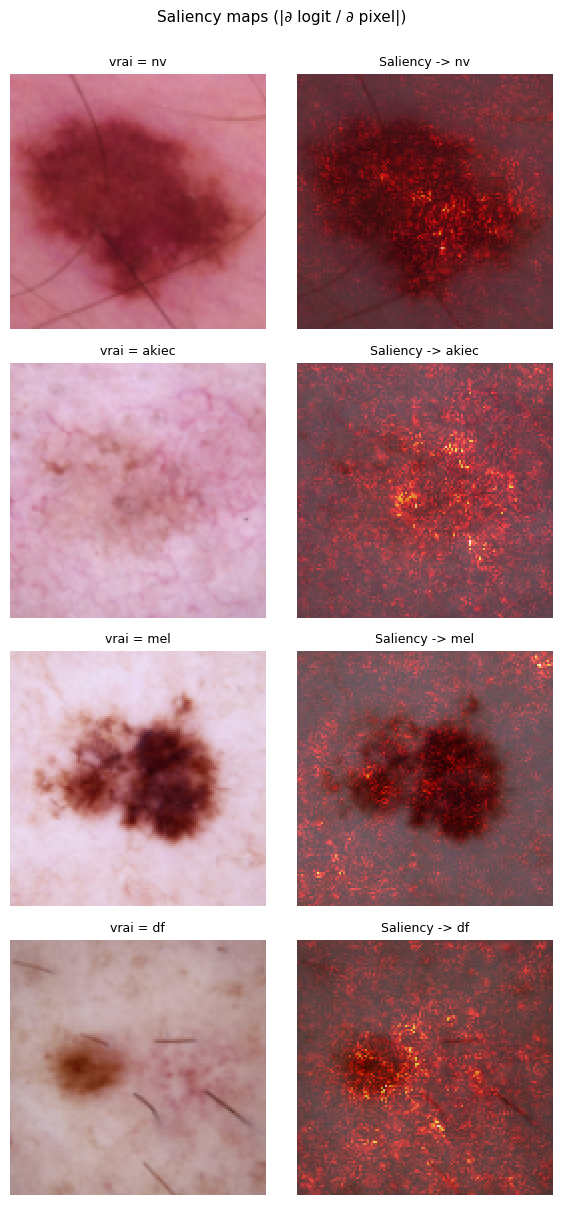

In [5]:
def saliency_map(model, x3, target=None):
    """x3 : tenseur (3,H,W) normalisé. Retourne (carte HxW dans [0,1], classe cible)."""
    model.eval()
    x = x3.clone().detach().unsqueeze(0).to(device).contiguous().requires_grad_(True)
    logits = model(x)
    if target is None:
        target = int(logits.argmax(1))
    model.zero_grad()
    logits[0, target].backward()
    g = x.grad.detach()[0].abs().amax(0)                 # max sur les canaux -> (H,W)
    g = (g - g.min()) / (g.max() - g.min() + 1e-8)
    return g.cpu().numpy(), target

n = len(samples)
fig, axes = plt.subplots(n, 2, figsize=(6, 3 * n)); axes = np.array(axes).reshape(n, 2)
for r, s in enumerate(samples):
    sal, _ = saliency_map(model, s["x"], s["pred"])
    axes[r, 0].imshow(disps[r]); axes[r, 0].axis("off")
    axes[r, 0].set_title(f"vrai = {CLASSES_SHORT[s['true']]}", fontsize=9)
    axes[r, 1].imshow(disps[r]); axes[r, 1].imshow(sal, cmap="hot", alpha=0.6); axes[r, 1].axis("off")
    axes[r, 1].set_title(f"Saliency -> {CLASSES_SHORT[s['pred']]}", fontsize=9)
plt.suptitle("Saliency maps (|∂ logit / ∂ pixel|)", y=1.0, fontsize=11)
plt.tight_layout(); plt.show()

**Interprétation — Saliency.** *Granularité : le pixel* (la plus fine, mais la plus bruitée). On lit l'intensité de $|\partial f_c/\partial x|$ : plus c'est clair sur la palette `hot`, plus le pixel est *sensible* localement.

- Pour `nv` et `mel`, le nuage de gradient **recouvre grossièrement la lésion** (bon signe) mais reste **granuleux et déborde** sur la peau saine.
- Pour `akiec` (lésion diffuse, peu contrastée), la carte se **disperse sur toute l'image** : le gradient brut ne sait pas localiser une lésion peu marquée.

C'est exactement la limite annoncée dans le cours : *bruitée mais quasi gratuite* (1 seul backward). À réserver à un **diagnostic rapide**, puis à lisser (SmoothGrad, Exercice 1) ou à confirmer par une méthode spatialisée comme Grad-CAM.

## Partie IV — Grad-CAM

On accroche deux **hooks** sur la dernière couche convolutive (`layer4[-1]`) : un *forward hook* pour capturer les activations $A^k$, un *full backward hook* pour capturer les gradients $\partial f_c/\partial A^k$. On en déduit les poids $\alpha_c^k$ (GAP du gradient), la combinaison linéaire, le ReLU, puis le suréchantillonnage à la taille de l'image.

> **Astuce graphe** : pour que les gradients **arrivent** jusqu'aux activations alors que le backbone peut être gelé (`requires_grad=False`), on force `x.requires_grad_(True)` — il faut au moins une feuille du graphe qui demande le gradient.

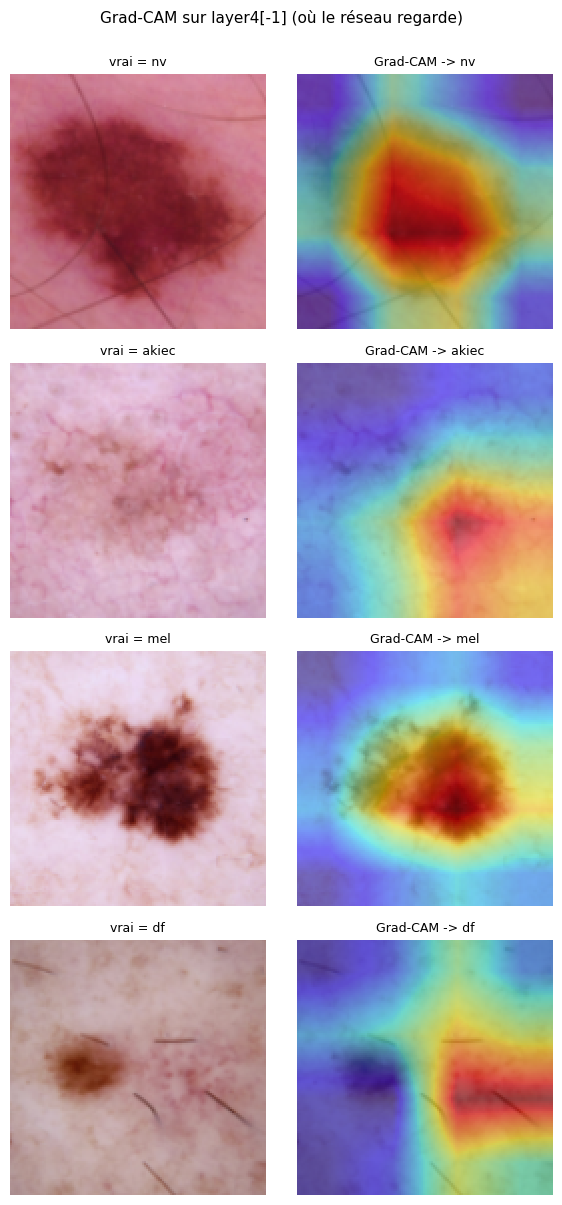

In [6]:
class GradCAM:
    """Grad-CAM via forward/backward hooks sur une couche convolutive cible."""
    def __init__(self, model, target_layer):
        self.model = model.eval(); self.A = None; self.G = None
        self.h1 = target_layer.register_forward_hook(self._fwd)
        self.h2 = target_layer.register_full_backward_hook(self._bwd)
    def _fwd(self, m, i, o): self.A = o.detach()
    def _bwd(self, m, gi, go): self.G = go[0].detach()
    def __call__(self, x3, target=None):
        x = x3.clone().detach().unsqueeze(0).to(device).contiguous().requires_grad_(True)
        logits = self.model(x)
        if target is None:
            target = int(logits.argmax(1))
        self.model.zero_grad(); logits[0, target].backward()
        A, G  = self.A[0], self.G[0]                     # (K,h,w)
        alpha = G.mean(dim=(1, 2))                        # (K,) -> GAP du gradient
        cam   = torch.relu((alpha[:, None, None] * A).sum(0))
        cam   = cam / (cam.max() + 1e-8)
        cam   = F.interpolate(cam[None, None], size=x3.shape[-2:],
                              mode="bilinear", align_corners=False)[0, 0]
        return cam.cpu().numpy(), target
    def remove(self): self.h1.remove(); self.h2.remove()

cam_engine = GradCAM(model, model.layer4[-1])

n = len(samples)
fig, axes = plt.subplots(n, 2, figsize=(6, 3 * n)); axes = np.array(axes).reshape(n, 2)
for r, s in enumerate(samples):
    cam, _ = cam_engine(s["x"], s["pred"])
    axes[r, 0].imshow(disps[r]); axes[r, 0].axis("off")
    axes[r, 0].set_title(f"vrai = {CLASSES_SHORT[s['true']]}", fontsize=9)
    axes[r, 1].imshow(disps[r]); axes[r, 1].imshow(cam, cmap="jet", alpha=0.5); axes[r, 1].axis("off")
    axes[r, 1].set_title(f"Grad-CAM -> {CLASSES_SHORT[s['pred']]}", fontsize=9)
plt.suptitle("Grad-CAM sur layer4[-1] (où le réseau regarde)", y=1.0, fontsize=11)
plt.tight_layout(); plt.show()

**Interprétation — Grad-CAM (le cœur de l'audit).** *Granularité : la zone grossière* (≈4×4 ré-agrandie). Grad-CAM répond à « **où** le réseau a-t-il regardé ? » ; en rouge, les régions où `layer4` s'active *en faveur* de la classe prédite.

| Image | Où tombe la zone chaude | Lecture |
|---|---|---|
| `nv`    | **centrée sur la lésion** | explication **saine** |
| `mel`   | **sur la lésion** | explication **saine** |
| `akiec` | décalée, lésion très diffuse | **fragile**, à surveiller |
| `df`    | **nettement à droite** de la lésion (en bas à gauche) | ⚠ **drapeau rouge** |

Le cas `df` est le plus instructif : le modèle prédit *juste* (`df`, conf 0.69) mais **regarde à côté** de la lésion. C'est précisément le **signal d'alarme** du cours — l'exemple « **husky vs loup** » où le classifieur regardait en réalité la **neige** du fond : *avoir raison pour une mauvaise raison*. Ce type de raccourci est **invisible dans l'accuracy** et n'apparaît qu'à l'audit. C'est pourquoi Grad-CAM est l'outil de **première intention** en imagerie médicale : il rend ce défaut visible d'un coup d'œil.

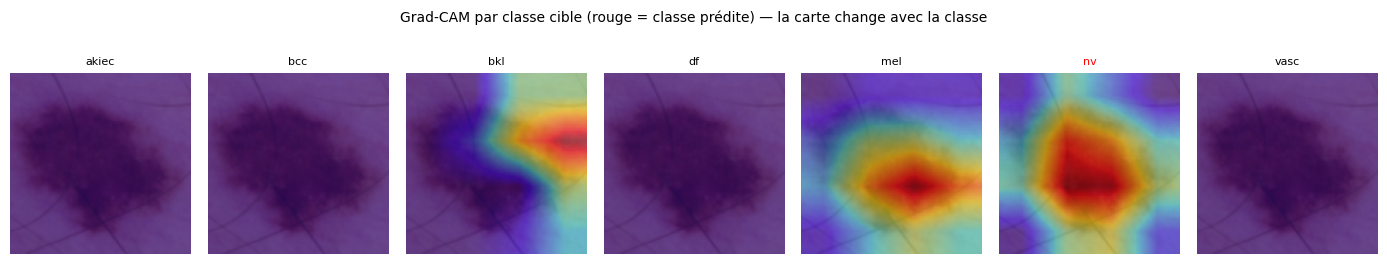

In [7]:
# Class-discrimination : la même image, une carte Grad-CAM PAR classe cible
s = samples[0]
fig, axes = plt.subplots(1, NUM_CLASSES, figsize=(2.0 * NUM_CLASSES, 2.4))
for c in range(NUM_CLASSES):
    cam, _ = cam_engine(s["x"], c)
    axes[c].imshow(disps[0]); axes[c].imshow(cam, cmap="jet", alpha=0.5); axes[c].axis("off")
    axes[c].set_title(CLASSES_SHORT[c], fontsize=8,
                      color=("red" if c == s["pred"] else "black"))
plt.suptitle("Grad-CAM par classe cible (rouge = classe prédite) — la carte change avec la classe",
             y=1.08, fontsize=10)
plt.tight_layout(); plt.show()
cam_engine.remove()

**Interprétation — class-discriminance.** Même image (`nv`), une carte **par classe cible** (titre rouge = classe prédite). La carte **change avec la classe demandée** :

- `nv` (prédite) et `mel` — deux lésions **pigmentées** — posent leur chaleur **sur la lésion** ;
- `bkl` active plutôt un **bord** de l'image ;
- les classes non pertinentes ici (`bcc`, `df`, `vasc`, `akiec`) restent **froides/uniformes** : rien dans l'image ne les soutient.

C'est la propriété clé du cours : Grad-CAM est **class-discriminant** — il explique *la* classe interrogée, pas « l'image en général ». Que `nv` et `mel` partagent la même zone d'intérêt est **cohérent cliniquement** (l'ambiguïté nævus ↔ mélanome est le cœur du diagnostic dermatoscopique) et révèle **où** le modèle peut hésiter entre ces deux classes.

## Partie V — Integrated Gradients

Somme de Riemann le long du chemin droit baseline → image. On **vérifie la complétude** : $\sum_i \mathrm{IG}_i$ doit égaler $f_c(x) - f_c(x')$ (aux erreurs de discrétisation près). C'est aussi un excellent **test de sanité** de l'implémentation.

Complétude : Σ IG = +8.8525  vs  f_c(x) - f_c(baseline) = +8.9943  (écart = 0.1417)


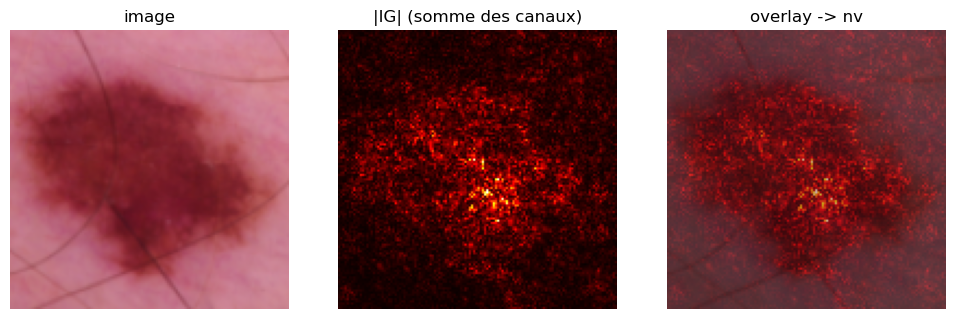

In [8]:
def integrated_gradients(model, x3, target=None, baseline=None, steps=50):
    """Retourne (IG (3,H,W), classe, f_c(x), f_c(baseline))."""
    model.eval()
    x0 = x3.clone().detach().unsqueeze(0).to(device).contiguous()
    if baseline is None:
        baseline = torch.zeros_like(x0)                  # = gris moyen ImageNet
    with torch.no_grad():
        if target is None:
            target = int(model(x0).argmax(1))
        F_x = float(model(x0)[0, target]); F_b = float(model(baseline)[0, target])
    grads = torch.zeros_like(x0)
    for k in range(1, steps + 1):
        a  = k / steps
        xi = (baseline + a * (x0 - baseline)).clone().requires_grad_(True)
        model.zero_grad(); model(xi)[0, target].backward()
        grads += xi.grad.detach()
    ig = ((x0 - baseline) * grads / steps)[0]            # (3,H,W)
    return ig.cpu(), target, F_x, F_b

s = samples[0]
ig, tgt, Fx, Fb = integrated_gradients(model, s["x"], s["pred"], steps=64)
total = float(ig.sum())
print(f"Complétude : Σ IG = {total:+.4f}  vs  f_c(x) - f_c(baseline) = {Fx - Fb:+.4f}  "
      f"(écart = {abs(total - (Fx - Fb)):.4f})")

ig_map = ig.abs().sum(0); ig_map = (ig_map / (ig_map.max() + 1e-8)).numpy()
fig, axes = plt.subplots(1, 3, figsize=(10, 3.2))
axes[0].imshow(disps[0]); axes[0].set_title("image"); axes[0].axis("off")
axes[1].imshow(ig_map, cmap="hot"); axes[1].set_title("|IG| (somme des canaux)"); axes[1].axis("off")
axes[2].imshow(disps[0]); axes[2].imshow(ig_map, cmap="hot", alpha=0.6)
axes[2].set_title(f"overlay -> {CLASSES_SHORT[s['pred']]}"); axes[2].axis("off")
plt.tight_layout(); plt.show()

**Interprétation — Integrated Gradients & test de complétude.** *Granularité : le pixel, mais axiomatique* — contrairement à Saliency, IG ne **sature** pas (un pixel important garde une attribution non nulle même là où le gradient local s'annule). La carte fait ressortir la **texture interne** de la lésion (réseau pigmentaire, points), pas seulement son contour.

**Vérification numérique de l'axiome de complétude** : on obtient $\sum_i \mathrm{IG}_i = +8.85$ contre $f_c(x) - f_c(x') = +8.99$, soit un **écart de 0.14 (< 2 %)**. Les attributions se **somment bien à l'écart de logit** entre l'image et la baseline : *rien n'est perdu*, chaque pixel reçoit sa juste part. Le petit résidu n'est que l'**erreur de discrétisation** de l'intégrale (somme de Riemann à `steps=64`) — l'augmenter le réduit encore. Cette égalité est le **meilleur test de sanité** d'une implémentation d'attribution : si elle échoue franchement, c'est que le code (hook, baseline, signe du logit) est faux.

## Partie VI — Occlusion sensitivity

Méthode par **perturbation** : on occulte un patch glissant et on mesure la chute de la probabilité de la classe prédite. Aucune dépendance aux gradients (*model-agnostic*) — fonctionne même sur une boîte noire.

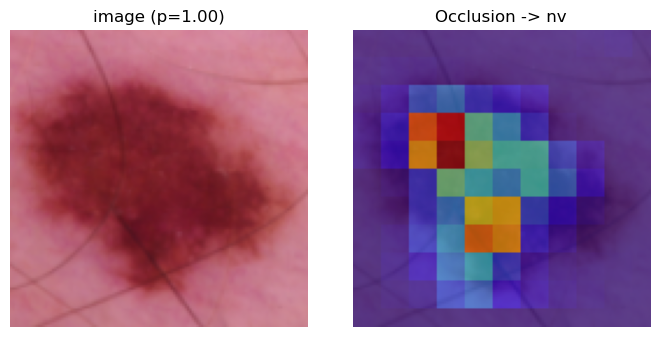

In [9]:
@torch.no_grad()
def occlusion(model, x3, target=None, patch=24, stride=12, fill=0.0):
    """Carte de chute de probabilité (HxW) quand un patch occulte chaque région."""
    model.eval()
    x = x3.clone().detach().unsqueeze(0).to(device).contiguous()
    logits = model(x)
    if target is None:
        target = int(logits.argmax(1))
    base = float(F.softmax(logits, 1)[0, target])
    H, W = x3.shape[-2:]
    heat = np.zeros((H, W)); cnt = np.zeros((H, W))
    for i in range(0, H - patch + 1, stride):
        for j in range(0, W - patch + 1, stride):
            xo = x.clone(); xo[:, :, i:i + patch, j:j + patch] = fill
            s_ij = float(F.softmax(model(xo), 1)[0, target])
            heat[i:i + patch, j:j + patch] += (base - s_ij)
            cnt[i:i + patch, j:j + patch]  += 1
    heat /= np.maximum(cnt, 1)
    heat = np.clip(heat, 0, None); heat /= (heat.max() + 1e-8)
    return heat, target, base

s = samples[0]
heat, _, base = occlusion(model, s["x"], s["pred"], patch=24, stride=12)
fig, axes = plt.subplots(1, 2, figsize=(7, 3.4))
axes[0].imshow(disps[0]); axes[0].set_title(f"image (p={base:.2f})"); axes[0].axis("off")
axes[1].imshow(disps[0]); axes[1].imshow(heat, cmap="jet", alpha=0.55)
axes[1].set_title(f"Occlusion -> {CLASSES_SHORT[s['pred']]}"); axes[1].axis("off")
plt.tight_layout(); plt.show()

**Interprétation — Occlusion.** *Famille perturbation, model-agnostic.* On lit directement une **chute de probabilité** : en rouge (`jet`), les zones dont l'occultation fait **le plus chuter** $p(\text{nv})$ — donc les zones **décisives**. Aucun gradient requis : la méthode fonctionne même sur une **boîte noire** (API, modèle non différentiable).

Les patchs les plus « coûteux » à masquer tombent sur le **cœur sombre de la lésion** (plus un foyer secondaire en dessous) — **même conclusion que Grad-CAM et IG**, mais obtenue par une famille **différente** : la confiance dans l'explication augmente. Le grain de la carte reflète la **taille du patch** (`patch=24, stride=12`) : trop petit → rien ne bouge ; trop grand → carte diffuse (cf. pièges, Partie X).

## Partie VII — LIME (superpixels)

Si `scikit-image` est disponible, on segmente l'image en superpixels **SLIC** ; sinon on retombe sur une **grille** régulière. On échantillonne des masques binaires, on prédit la probabilité de la classe cible sur chaque image perturbée, et on ajuste une **régression Ridge pondérée** : les coefficients colorent chaque superpixel (vert = soutient la classe, rouge = défavorise).

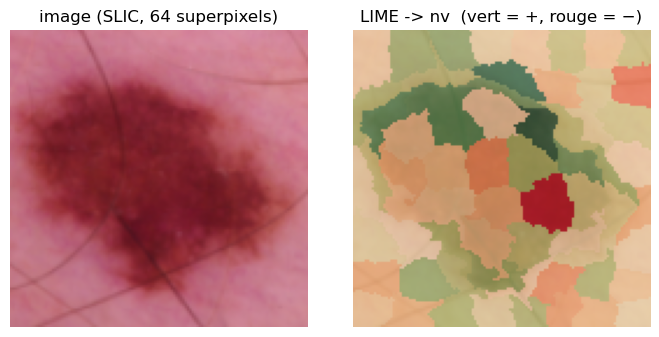

Importances des 3 superpixels les plus favorables : [0.083 0.074 0.06 ]


In [10]:
def _segment(disp, n_segments):
    H, W, _ = disp.shape
    if HAS_SKIMAGE:
        try:
            return slic(disp, n_segments=n_segments, compactness=10, start_label=0, channel_axis=-1)
        except TypeError:
            return slic(disp, n_segments=n_segments, compactness=10, multichannel=True)
    gs = 16                                              # repli : grille 16x16
    ys, xs = np.arange(H) // gs, np.arange(W) // gs
    return ys[:, None] * (W // gs + 1) + xs[None, :]

def lime_explain(model, disp, target=None, n_samples=400, n_segments=60,
                 sigma=0.30, batch=64, seed=SEED):
    H, W, _ = disp.shape
    segments = _segment(disp, n_segments)
    ids = np.unique(segments); remap = {v: i for i, v in enumerate(ids)}
    segments = np.vectorize(remap.get)(segments); n_seg = len(ids)
    if target is None:
        with torch.no_grad():
            target = int(model(disp_to_input(disp).unsqueeze(0).to(device).contiguous()).argmax(1))
    rng = np.random.default_rng(seed)
    Z = rng.integers(0, 2, size=(n_samples, n_seg)); Z[0] = 1     # 1er échantillon = image complète
    fill = disp.mean(axis=(0, 1))                                  # couleur neutre = moyenne
    preds = np.zeros(n_samples)
    for st in range(0, n_samples, batch):
        zb, imgs = Z[st:st + batch], []
        for z in zb:
            m = z[segments][..., None].astype(np.float32)
            imgs.append(disp_to_input((disp * m + (1 - m) * fill).astype(np.float32)))
        xb = torch.stack(imgs).to(device)
        with torch.no_grad():
            preds[st:st + len(zb)] = F.softmax(model(xb), 1)[:, target].cpu().numpy()
    d  = np.sqrt(((Z - 1.0) ** 2).sum(1))                          # distance à l'image complète
    w  = np.exp(-(d ** 2) / (sigma * n_seg))                       # noyau de proximité
    coef = Ridge(alpha=1.0).fit(Z, preds, sample_weight=w).coef_
    imp = np.zeros((H, W))
    for k in range(n_seg):
        imp[segments == k] = coef[k]
    return imp, target, segments, coef

s = samples[0]
imp, tgt, segs, coef = lime_explain(model, disps[0], s["pred"], n_samples=400)
vmax = np.abs(imp).max() + 1e-8
fig, axes = plt.subplots(1, 2, figsize=(7, 3.4))
axes[0].imshow(disps[0]); axes[0].axis("off")
axes[0].set_title(f"image ({'SLIC' if HAS_SKIMAGE else 'grille'}, {len(coef)} superpixels)")
axes[1].imshow(disps[0]); axes[1].imshow(imp, cmap="RdYlGn", alpha=0.6, vmin=-vmax, vmax=vmax)
axes[1].set_title(f"LIME -> {CLASSES_SHORT[s['pred']]}  (vert = +, rouge = −)"); axes[1].axis("off")
plt.tight_layout(); plt.show()
print("Importances des 3 superpixels les plus favorables :", np.sort(coef)[::-1][:3].round(3))

**Interprétation — LIME.** *Granularité : la région (superpixel).* On lit le **signe** du coefficient de la régression linéaire locale : **vert = soutient** la classe, **rouge = s'y oppose**. Les superpixels verts se concentrent sur/autour de la lésion — cohérent.

Deux nuances **importantes** :
1. les coefficients sont **petits** (top-3 ≈ 0.083 / 0.074 / 0.060) : l'explication locale est *modeste* en amplitude ;
2. un superpixel **rouge** peut apparaître **au centre même de la lésion** — symptôme de l'**instabilité** de LIME (sensible au tirage aléatoire des masques, à $\sigma$, au nombre de superpixels).

**Réflexe** : ré-exécuter plusieurs fois (seeds différents) et **moyenner** avant de conclure. LIME reste précieux pour **présenter** une explication par régions à un expert métier : sortie *model-agnostic* et lisible, même sans accès aux gradients.

## Partie VIII — SHAP par Expected Gradients (GradientSHAP)

On approxime les valeurs de Shapley en moyennant `grad × (x − baseline)` sur des **baselines tirées du jeu d'entraînement** et des points aléatoires du chemin. C'est l'algorithme **GradientSHAP** ; la bibliothèque `shap` en fournit une version optimisée (`shap.GradientExplainer`).

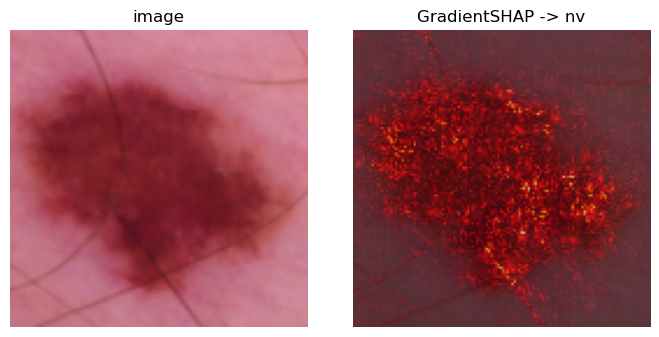

`shap` disponible : voir shap.GradientExplainer pour une version optimisée et des force plots.


In [11]:
# Jeu d'arrière-plan = échantillon d'images de train (la "référence moyenne")
bg_idx = np.random.default_rng(SEED).choice(len(train_set), size=32, replace=False)
background = torch.stack([train_set[int(i)][0] for i in bg_idx]).to(device)

def expected_gradients(model, x3, background, target=None, n_samples=64, seed=SEED):
    model.eval()
    x = x3.clone().detach().unsqueeze(0).to(device).contiguous()
    if target is None:
        with torch.no_grad():
            target = int(model(x).argmax(1))
    g   = torch.zeros_like(x)
    gen = torch.Generator(device=device).manual_seed(seed)
    nb  = background.shape[0]
    for _ in range(n_samples):
        b  = background[int(torch.randint(0, nb, (1,), generator=gen, device=device)):][:1]
        a  = float(torch.rand(1, generator=gen, device=device))
        xi = (b + a * (x - b)).clone().requires_grad_(True)
        model.zero_grad(); model(xi)[0, target].backward()
        g += xi.grad.detach() * (x - b)
    return (g / n_samples)[0].cpu(), target

s = samples[0]
eg, _ = expected_gradients(model, s["x"], background, s["pred"], n_samples=64)
eg_map = eg.abs().sum(0); eg_map = (eg_map / (eg_map.max() + 1e-8)).numpy()
fig, axes = plt.subplots(1, 2, figsize=(7, 3.4))
axes[0].imshow(disps[0]); axes[0].set_title("image"); axes[0].axis("off")
axes[1].imshow(disps[0]); axes[1].imshow(eg_map, cmap="hot", alpha=0.6)
axes[1].set_title(f"GradientSHAP -> {CLASSES_SHORT[s['pred']]}"); axes[1].axis("off")
plt.tight_layout(); plt.show()

if HAS_SHAP:
    print("`shap` disponible : voir shap.GradientExplainer pour une version optimisée et des force plots.")
else:
    print("`shap` non installé — implémentation maison Expected Gradients (équivalente à GradientSHAP).")

**Interprétation — GradientSHAP / Expected Gradients.** *Granularité : le pixel*, comme IG — mais la baseline n'est plus une seule image noire : on **moyenne sur un jeu d'arrière-plan** $\mathcal{D}_{\text{bg}}$ (32 images de *train*) **et** sur des points aléatoires du chemin. C'est une **généralisation stochastique des IG** qui approxime les **valeurs de Shapley** (propriété d'**efficacité** : $\sum_i \phi_i = f(x) - \mathbb{E}[f]$).

La carte est **très proche de celle des IG** — concentrée sur la texture interne de la lésion — ce qui est **attendu** (même famille gradient). Son intérêt propre : la baseline « moyenne du dataset » fournit une attribution **relative au cas typique** plutôt qu'au noir absolu, souvent plus parlante pour répondre à « qu'est-ce qui rend **cette** image différente de la moyenne ? ».

## Partie IX — Consensus des méthodes & validation croisée

On superpose toutes les attributions sur la même image. Quand plusieurs familles (gradient, perturbation, jeux) **convergent** sur la même région, la confiance dans l'explication augmente. On **croise** ensuite nos implémentations avec **Captum** (corrélation de Pearson) — un test direct de correction.

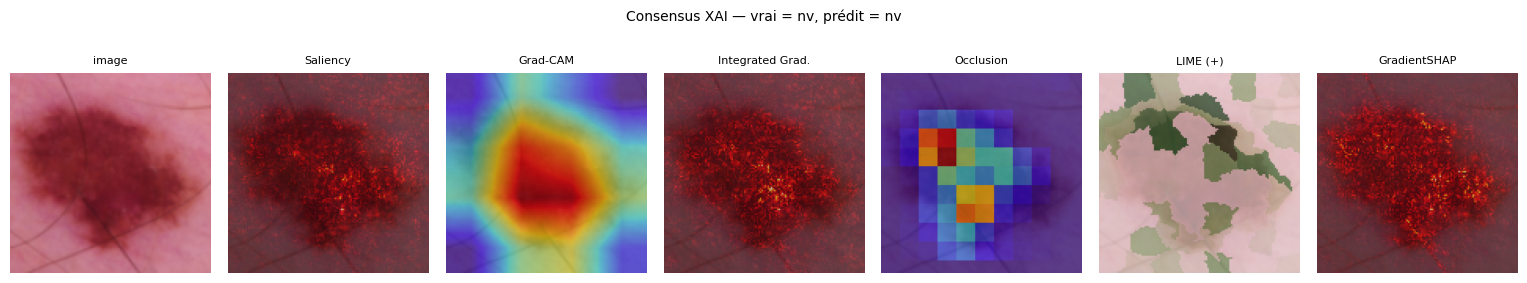

In [12]:
s, d = samples[0], disps[0]
sal, _              = saliency_map(model, s["x"], s["pred"])
ce = GradCAM(model, model.layer4[-1]); cam, _ = ce(s["x"], s["pred"]); ce.remove()
ig, _, _, _         = integrated_gradients(model, s["x"], s["pred"], steps=48)
igm = ig.abs().sum(0); igm = (igm / (igm.max() + 1e-8)).numpy()
heat, _, _          = occlusion(model, s["x"], s["pred"], patch=24, stride=12)
imp, _, _, _        = lime_explain(model, d, s["pred"], n_samples=300)
impn = np.clip(imp, 0, None); impn /= (impn.max() + 1e-8)
eg, _               = expected_gradients(model, s["x"], background, s["pred"], n_samples=48)
egm = eg.abs().sum(0); egm = (egm / (egm.max() + 1e-8)).numpy()

panels = [("image", None, None), ("Saliency", sal, "hot"), ("Grad-CAM", cam, "jet"),
          ("Integrated Grad.", igm, "hot"), ("Occlusion", heat, "jet"),
          ("LIME (+)", impn, "Greens"), ("GradientSHAP", egm, "hot")]
fig, axes = plt.subplots(1, len(panels), figsize=(2.2 * len(panels), 2.6))
for ax, (name, m, cmap) in zip(axes, panels):
    ax.imshow(d)
    if m is not None:
        ax.imshow(m, cmap=cmap, alpha=0.55)
    ax.set_title(name, fontsize=8); ax.axis("off")
plt.suptitle(f"Consensus XAI — vrai = {CLASSES_SHORT[s['true']]}, prédit = {CLASSES_SHORT[s['pred']]}",
             y=1.07, fontsize=10)
plt.tight_layout(); plt.show()

**Interprétation — consensus multi-méthodes.** On juxtapose ici les **trois granularités** du cours sur la même image `nv` : **pixel** (Saliency, Integrated Gradients, GradientSHAP), **zone** (Grad-CAM, Occlusion) et **région** (LIME).

Les **six** méthodes — issues de **familles différentes** (gradient, perturbation, théorie des jeux, approximation locale) — **convergent sur la lésion**. C'est le scénario idéal d'un audit : quand des approches qui ne partagent ni les mêmes hypothèses ni les mêmes biais pointent **la même région**, la confiance dans l'explication est **maximale**. À l'inverse, un désaccord franc (une seule méthode qui dévie) signale soit un artefact *de la méthode*, soit une zone d'ombre *du modèle* à creuser.

Rappel : le consensus n'est montré que pour `nv` (cas **sain**). Refaire l'exercice sur `df` ferait ressortir le **désaccord** déjà repéré au Grad-CAM — un excellent réflexe d'audit que l'on systématise en Partie X.

In [13]:
!pip install scikit-image captum shap --quiet

In [14]:
# Validation croisée avec Captum (si installé) : corrélation avec nos implémentations
if HAS_CAPTUM:
    from captum.attr import IntegratedGradients as CaptumIG, LayerGradCam, LayerAttribution
    s = samples[0]; x = s["x"].unsqueeze(0).to(device).contiguous()

    a_ig = CaptumIG(model).attribute(x, target=s["pred"],
                                     baselines=torch.zeros_like(x), n_steps=64)
    our_ig, _, _, _ = integrated_gradients(model, s["x"], s["pred"], steps=64)
    c_ig = np.corrcoef(a_ig[0].abs().sum(0).flatten().cpu().numpy(),
                       our_ig.abs().sum(0).flatten().numpy())[0, 1]

    lgc   = LayerGradCam(model, model.layer4[-1])
    a_cam = lgc.attribute(x, target=s["pred"])
    a_cam = LayerAttribution.interpolate(a_cam, x.shape[-2:]).relu()[0, 0].detach().cpu().numpy()
    ce = GradCAM(model, model.layer4[-1]); our_cam, _ = ce(s["x"], s["pred"]); ce.remove()
    c_cam = np.corrcoef(a_cam.flatten(), our_cam.flatten())[0, 1]

    print(f"Corrélation Integrated Gradients (Captum vs maison) : {c_ig:.3f}")
    print(f"Corrélation Grad-CAM             (Captum vs maison) : {c_cam:.3f}")
    print("(proche de 1.0 attendu -> implémentations validées)")
else:
    print("Captum non installé — validation croisée ignorée.  `pip install captum` pour l'activer.")

Corrélation Integrated Gradients (Captum vs maison) : 0.999
Corrélation Grad-CAM             (Captum vs maison) : 0.919
(proche de 1.0 attendu -> implémentations validées)


**Interprétation — validation croisée avec Captum.** On compare nos implémentations « maison » à la bibliothèque officielle **Captum** via la **corrélation de Pearson** des cartes : **IG = 0.999** (quasi identique) et **Grad-CAM = 0.919** (très forte). L'écart résiduel sur Grad-CAM est **normal** : différences de **suréchantillonnage/interpolation** et de gestion du `ReLU`/normalisation entre les deux codes. Une corrélation proche de 1 **valide** que notre code *from scratch* calcule bien la même chose que l'outil de référence — exactement la démarche du cours : **implémenter à la main pour comprendre, puis croiser avec l'API** (Captum) pour la production.

## Partie X — Lecture, pièges et audit du modèle

### Bilan de l'audit (4 prédictions correctes et confiantes)

En croisant toutes les méthodes ci-dessus, on peut **statuer image par image**. Ce modèle (test acc ≈ **0.67**) regarde *globalement* la lésion sur les cas pigmentés — **mais pas toujours** :

| Image | Prédiction (conf.) | Où regarde le modèle | Verdict |
|---|---|---|---|
| `nv`    | nv (1.00)    | cœur de la lésion — **consensus des 6 méthodes** | **sain** |
| `mel`   | mel (0.91)   | sur la lésion | **sain** |
| `akiec` | akiec (0.82) | zone décalée, lésion très diffuse | **fragile** (à surveiller) |
| `df`    | df (0.69)    | **à côté** de la lésion (Grad-CAM) | **drapeau rouge** — raccourci probable |

Le cas `df` résume la leçon centrale : *une bonne accuracy ne garantit pas une bonne raison*. Le modèle a **raison pour une mauvaise raison** — l'exact analogue du piège « **husky vs loup** » (Ribeiro et al., 2016), où le classifieur regardait la **neige** de l'arrière-plan. Ce raccourci est **invisible** sur la seule métrique et n'apparaît qu'à l'**audit XAI**.

**Comment lire ces cartes ?**
- Les régions chaudes (Saliency / IG / SHAP) ou en surbrillance (Grad-CAM / Occlusion) doivent coïncider avec la **lésion**, pas avec le **fond**, un **poil**, une **règle** ou une **vignette**.
- Un modèle correct mais qui « regarde au mauvais endroit » est un **drapeau rouge** (raccourci) même si l'accuracy est bonne.

**Pièges méthodologiques**
- **Saliency** très bruité → préférer SmoothGrad (moyenne sur du bruit) pour un rendu lisible.
- **Grad-CAM** est *grossier* (résolution de `layer4`) : il localise une zone, pas un contour fin (→ Grad-CAM++, HiResCAM).
- **Integrated Gradients / SHAP** dépendent de la **baseline** : tester plusieurs (noir, gris, bruit) et comparer.
- **LIME** est **instable** (dépend du seed d'échantillonnage, de $\sigma$, du nombre de superpixels) : ré-exécuter plusieurs fois.
- **Occlusion** dépend de la **taille du patch** : trop petit → rien ne change ; trop grand → carte diffuse.

**Bonne pratique d'audit** : combiner **plusieurs méthodes**, comparer à des annotations expertes, et tester la robustesse (les explications restent-elles stables après un léger changement d'acquisition ?).

**Que faire quand on détecte un raccourci ?** Corriger d'abord les **données** (retirer/atténuer les artefacts : poils, règles, vignettes d'hôpital ; recadrer sur la lésion ; rééquilibrer ou augmenter la classe concernée), **pas seulement le modèle** — puis **re-auditer**. C'est le réflexe d'audit du cours : l'explication *pointe* le problème, mais la correction se joue souvent en amont, sur le jeu de données.

## Partie XI — Exercices d'application

### Exercice 1 — SmoothGrad
Ajoutez du bruit gaussien $\mathcal{N}(0,\sigma^2)$ à l'image ($n=25$ tirages), moyennez les saliency maps. Comparez la lisibilité à la saliency brute.

### Exercice 2 — Grad-CAM++
Implémentez Grad-CAM++ (pondération par les gradients d'ordre 2) et comparez à Grad-CAM sur une image contenant plusieurs structures.

### Exercice 3 — Sensibilité à la baseline (IG)
Recalculez les Integrated Gradients avec 3 baselines (noir $= -\mu/\sigma$, gris moyen $= 0$, bruit gaussien). La complétude tient-elle dans les 3 cas ? Les cartes diffèrent-elles ?

### Exercice 4 — Couche cible de Grad-CAM
Comparez Grad-CAM calculé sur `layer2`, `layer3`, `layer4`. Que gagne / perd-on en résolution vs sémantique ?

### Exercice 5 — Détection de raccourci (*shortcut*)
Collez artificiellement un petit carré coloré dans un coin de toutes les images d'une classe, ré-entraînez la tête, puis vérifiez avec Grad-CAM / Occlusion que le modèle s'est mis à **regarder le carré**.

### Exercice 6 — Fidélité (*deletion metric*)
Supprimez progressivement les pixels les plus importants d'une carte et tracez la chute de probabilité (courbe *deletion*). Comparez Grad-CAM vs IG vs LIME (aire sous la courbe : plus petite = plus fidèle).

### Exercice 7 — Captum complet
Avec `captum`, comparez `Saliency`, `IntegratedGradients`, `DeepLift`, `GradientShap`, `Occlusion`, `LayerGradCam` sur la même image via `captum.attr.visualization`.

## Synthèse — méthodes XAI et API

| Méthode | Famille | Modèle requis | Coût | API (Captum / lib) |
|---|---|---|---|---|
| Saliency | Gradient | différentiable | très faible | `captum.attr.Saliency` |
| Grad-CAM | Gradient (CNN) | convolutif | faible | `captum.attr.LayerGradCam` |
| Integrated Gradients | Gradient axiomatique | différentiable | moyen | `captum.attr.IntegratedGradients` |
| Occlusion | Perturbation | boîte noire | élevé | `captum.attr.Occlusion` |
| LIME | Approx. locale | boîte noire | élevé | `lime.lime_image` |
| GradientSHAP | Théorie des jeux | différentiable | moyen | `captum.attr.GradientShap` / `shap` |

**Choix selon la situation**
- **Vision CNN** : Grad-CAM en première intention ; Integrated Gradients pour un audit fin.
- **Boîte noire** (API externe, modèle non différentiable) : LIME ou Occlusion.
- **Tabulaire** : SHAP (TreeSHAP si arbres, DeepSHAP si réseau).
- **ViT** (Module 4) : Attention Rollout / Transformer Attribution.

**Recommandations**
1. **Toujours croiser** ≥ 2 méthodes de familles différentes avant de conclure.
2. **Vérifier la complétude** (IG / SHAP) comme test de sanité de l'implémentation.
3. **Documenter la baseline** et les hyperparamètres (patch, $\sigma$, n_superpixels) : ils changent la carte.
4. Une bonne accuracy **ne garantit pas** une bonne raison — auditer *où* le modèle regarde.

---

*Fin du TP — Module 2 / Explicabilité (XAI). Suite : Module 3 — Autoencoders, VAE & Diffusion.*